# 02 — Model 1: Linear Baseline (band-power features + logistic regression)

This notebook trains **Model 1** of the thesis: a deliberately simple, *intrinsically
interpretable* classifier for ECG200. It works in two stages:

1. **Signal processing** — split each heartbeat into a few frequency bands and measure
   how much energy sits in each band (its *band power*).
2. **Classification** — fit a logistic regression on those band-power numbers.

**Why this model matters.** It is the **ground-truth anchor** for the whole project.
Because the logistic regression uses one feature per frequency band, its learned weights
tell us *exactly* which frequency bands the model relies on. Later, we will check whether
an explainability method (TimeSHAP) recovers those same bands. If it does, that is
evidence the explanation is faithful; if it does not, the explanation is suspect.

**Repo rule.** All reusable logic lives in `src/models/linear_baseline.py`; this notebook
only imports, runs, and narrates.

> Scope: this notebook is *only* about training and understanding Model 1. No XAI /
> TimeSHAP / CMI code appears here — that is a later step.

In [1]:
import sys
from pathlib import Path

# Add repo root to sys.path so the harness/ecg200 packages import when running from notebooks/
PROJECT_ROOT = Path.cwd().parent
REPO_ROOT = Path.cwd().parents[1]  # repo root: harness/, ecg200/, sleep_edf/
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

from ecg200.preprocessing import load_ecg200
from ecg200.linear_baseline import (
    DEFAULT_BANDS,
    extract_band_power_features,
    build_linear_baseline,
)

FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=3, suppress=True)

## 1. Load the data

We reuse the existing preprocessing pipeline via `load_ecg200(split)`. That function returns
the **per-sample z-scored** ECG traces already split into train / validation / test. We do
not re-implement any loading or normalisation here — we just call the pipeline and confirm we
got what we expect.

**What to look at in the output:**

- Shapes should be **80 train / 20 val / 100 test**, each with **96 timesteps**.
- The **class-1 share** (proportion of "normal" beats) should be similar across splits —
  that confirms the stratified split preserved the class balance.

In [2]:
X_train, y_train = load_ecg200("train")
X_val,   y_val   = load_ecg200("val")
X_test,  y_test  = load_ecg200("test")

print(f"{'split':<7}{'X shape':<14}{'y shape':<12}{'class-1 %':>10}")
print("-" * 43)
for name, X, y in [("train", X_train, y_train),
                   ("val",   X_val,   y_val),
                   ("test",  X_test,  y_test)]:
    print(f"{name:<7}{str(X.shape):<14}{str(y.shape):<12}{100 * y.mean():>9.1f}%")

split  X shape       y shape      class-1 %
-------------------------------------------
train  (80, 96)      (80,)            68.8%
val    (20, 96)      (20,)            70.0%
test   (100, 96)     (100,)           64.0%


### What we got

The splits are **80 / 20 / 100** with **96 timesteps** each, exactly as designed. The
class-1 ("normal" beat) share is **≈68.8% train, 70.0% val, 64.0% test** — close enough
across splits to confirm the stratification held. Two things to carry forward:

- The data is **mildly imbalanced** (roughly two-thirds normal). Plain accuracy is therefore
  a weak yardstick: a model that always predicts "normal" scores ~64% on the test set while
  learning nothing. We will report **balanced accuracy** and **F1** alongside accuracy.
- The **validation set is tiny (20 samples)**, so a single val prediction moves the score by
  5 percentage points. We will treat val as a rough read and reserve the 100-sample **test**
  set for the honest final number.

## 2. The concept first: what is a bandpass filter and "band power"?

Before any code, the idea in plain terms.

**A signal is a mix of wiggles at different speeds.** An ECG trace is one wavy line, but you
can think of it as many simple waves added together: slow, gentle rises and falls (low
frequency) plus fast, sharp spikes (high frequency). The sharp QRS spike of a heartbeat is
"fast" wiggling; the broad baseline drift and the rounded P- and T-waves are "slow" wiggling.

**A bandpass filter keeps one speed range and removes the rest.** Give it a low and a high
cutoff and it passes wiggles *between* those speeds while suppressing everything faster or
slower. A **low-pass** filter keeps only the slow stuff; a **high-pass** filter keeps only
the fast stuff; a **band-pass** keeps a middle range. We use a *Butterworth* filter (a
standard, smooth filter) applied with `filtfilt`, which filters the signal forwards and
backwards so it introduces **no time shift** — the filtered spike stays where the real spike
was. That matters for us, since we care about *where* energy is.

**Band power = how much energy lives in that speed range.** After filtering a trace down to
one band, we square it and average over time. Squaring makes every wiggle positive and
weights big swings more; averaging gives a single number per band. Loosely: **"how strong is
the signal's wiggling in this frequency range?"** Five bands → five numbers per heartbeat.
Those five numbers are the only thing the classifier ever sees.

## 3. Choosing the frequency bands (and an honest note on units)

**Normalised frequency — and why we avoid Hz in the code.** Frequency in physical units (Hz,
cycles per second) requires knowing the **sampling rate**: how many of the 96 samples occur
per second. **The UCR archive does not document a sampling rate for ECG200.** So we define
every band edge in **normalised frequency** — a fraction of the *Nyquist rate*, where `1.0`
means "the fastest wiggle the data can represent." This is completely independent of the
unknown sampling rate, and it is what `scipy.signal.butter` uses when no rate is supplied.
**All filtering below is in normalised units; no Hz value ever enters a computation.**

> ⚠️ **Assumption flag (interpretation only).** For intuition it helps to attach rough Hz
> labels. If one heartbeat (~0.8 s) spans 96 samples, then the sampling rate would be
> **fs ≈ 120 Hz** and Nyquist ≈ 60 Hz. **This is an assumption to verify, not a fact**, and
> it appears *only* in this explanatory text — never in the code.

**Five bands.** With only 80 training beats we want few features, and we want each to mean
something. Five bands, one band-power feature each, spanning slow to fast:

| Band | Normalised (× Nyquist) | ≈ Hz *(if fs≈120 — assumption)* | Filter | What it roughly captures |
|------|------------------------|--------------------------------|--------|--------------------------|
| B1 low       | 0.00 – 0.08 | 0 – 5 Hz   | low-pass  | baseline drift, P/T-wave energy |
| B2 low-mid   | 0.08 – 0.25 | 5 – 15 Hz  | band-pass | P/T-wave detail, QRS onset |
| B3 mid       | 0.25 – 0.42 | 15 – 25 Hz | band-pass | **QRS core energy** |
| B4 high      | 0.42 – 0.67 | 25 – 40 Hz | band-pass | sharp QRS edges |
| B5 very-high | 0.67 – 1.00 | 40 – 60 Hz | high-pass | high-frequency content / noise |

(The lowest band is a low-pass and the highest a high-pass, because a true band-pass cannot
reach all the way down to 0 or up to Nyquist.)

**A subtlety you must keep in mind when reading results later.** The traces are **per-sample
z-scored**, so every beat has roughly the *same total power*. That means the five band powers
**roughly sum to a constant** and are therefore **not independent** — they are mildly
*anti-correlated* by construction. Physically: the features describe **how a fixed energy
budget is distributed across frequencies**, not absolute energy. So a large weight on one band
is partly an implicit statement about the others. We return to this when reading coefficients.

### Extract the features

We call `extract_band_power_features` (from `src/`) on the training set. It band-filters the
whole batch five times and returns an `(80, 5)` matrix — one row per beat, one column per
band — plus the band names.

**What to look at:**

- The matrix shape should be `(80, 5)`.
- The **mean power per band**: expect it to be dominated by the low bands (ECG energy is
  mostly slow) and to fall off steeply toward the high bands.
- The **per-row sums**: expect them to be *roughly* constant (≈1) across beats — the
  z-scoring signature we just described.

In [3]:
F_train, band_names = extract_band_power_features(X_train)
F_val,   _          = extract_band_power_features(X_val)
F_test,  _          = extract_band_power_features(X_test)

print("feature matrix shape :", F_train.shape)
print("band names           :", band_names)
print()
print("mean band power per band (train):")
for name, val in zip(band_names, F_train.mean(axis=0)):
    print(f"  {name:<14}{val:.4f}")

row_sums = F_train.sum(axis=1)
print(f"\nper-row band-power sum: mean={row_sums.mean():.3f}  "
      f"min={row_sums.min():.3f}  max={row_sums.max():.3f}")

print("\nfeature correlation matrix (train):")
print(np.corrcoef(F_train.T))

feature matrix shape : (80, 5)
band names           : ['B1_low', 'B2_low_mid', 'B3_mid', 'B4_high', 'B5_very_high']

mean band power per band (train):
  B1_low        0.7534
  B2_low_mid    0.1174
  B3_mid        0.0289
  B4_high       0.0106
  B5_very_high  0.0047

per-row band-power sum: mean=0.915  min=0.814  max=1.005

feature correlation matrix (train):
[[ 1.    -0.755 -0.527 -0.347 -0.404]
 [-0.755  1.     0.008  0.202  0.21 ]
 [-0.527  0.008  1.     0.273  0.415]
 [-0.347  0.202  0.273  1.     0.627]
 [-0.404  0.21   0.415  0.627  1.   ]]


### What the features look like

The energy is overwhelmingly **low-frequency**: mean band power falls from **≈0.75 in B1**
to **≈0.005 in B5** — a heartbeat is mostly slow structure with a small fast QRS spike. The
per-row sums cluster near **≈0.9** with little spread, confirming the z-scoring fixes each
beat's total energy budget (it sits a touch below 1 because the filters shed a little energy
in their transition zones). The correlation matrix shows the promised effect: **B1 is
strongly anti-correlated with every other band (≈ −0.4 to −0.75)** — because B1 holds most of
the fixed budget, when it rises the others must fall. Read this as our standing reminder that
the bands compete for a shared budget rather than varying freely.

### Seeing what a feature measures

To make "band power" concrete, we plot two example beats (one from each class) together with
their five band-power values. This is just a visual aid — nothing is computed here that the
model uses beyond the features already extracted.

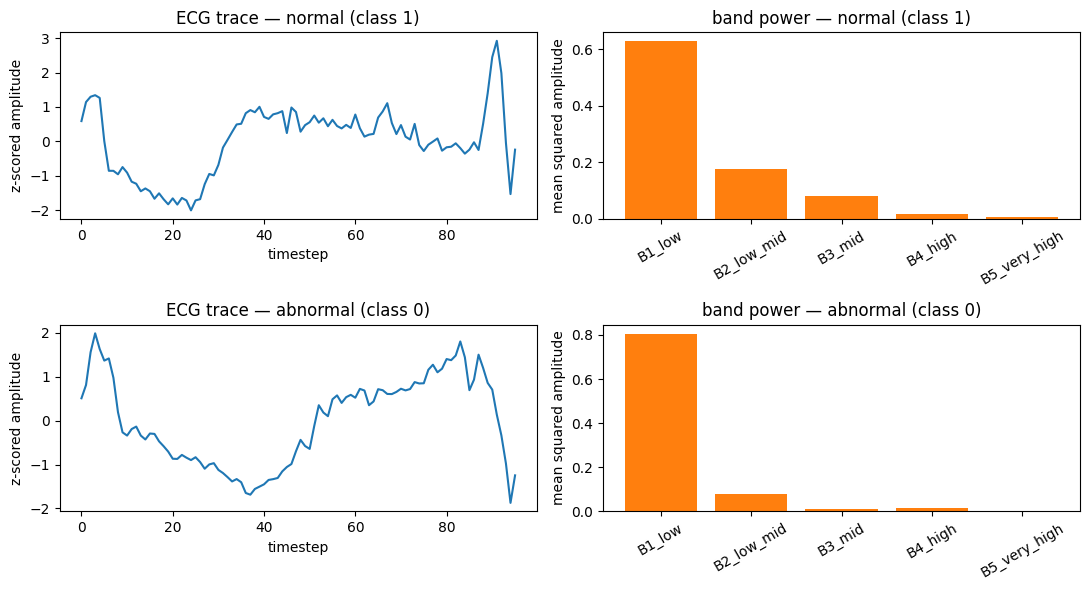

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
x_axis = np.arange(X_train.shape[1])

for row, cls in enumerate([1, 0]):          # 1 = normal, 0 = abnormal
    idx = np.where(y_train == cls)[0][0]     # first beat of this class
    label = "normal (class 1)" if cls == 1 else "abnormal (class 0)"

    axes[row, 0].plot(x_axis, X_train[idx], color="C0")
    axes[row, 0].set_title(f"ECG trace — {label}")
    axes[row, 0].set_xlabel("timestep")
    axes[row, 0].set_ylabel("z-scored amplitude")

    axes[row, 1].bar(band_names, F_train[idx], color="C1")
    axes[row, 1].set_title(f"band power — {label}")
    axes[row, 1].set_ylabel("mean squared amplitude")
    axes[row, 1].tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(FIG_DIR / "02_example_traces_band_power.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Train the logistic regression

**Why logistic regression?** It is the simplest sensible classifier that stays interpretable:
it learns one weight per feature and combines them linearly. Because we have one feature per
band, **one weight ↔ one frequency band** — exactly the clean map we need for the ground-truth
role.

**Two deliberate settings** (both handled inside `build_linear_baseline()` in `src/`):

- **`StandardScaler`** rescales each band-power feature to mean 0 / std 1, *fit on the
  training set only*. Without it, B1 (power ≈0.75) would dwarf B5 (≈0.005) purely because of
  scale, and the weights would not be comparable. With it, weight magnitudes are directly
  comparable across bands.
- **`class_weight="balanced"`** tells the classifier to care proportionally more about the
  minority (abnormal) class, so the ~65/35 imbalance does not push it toward always predicting
  "normal."

We fit on **train** and predict on **val** first.

In [5]:
model = build_linear_baseline()
model.fit(F_train, y_train)

y_val_pred = model.predict(F_val)
print("validation predictions:", y_val_pred)
print("validation truth      :", y_val)

validation predictions: [1 1 1 0 1 1 0 0 1 0 0 1 1 1 0 0 0 1 1 1]
validation truth      : [1 1 1 1 1 1 0 0 1 0 0 1 1 1 0 1 0 1 1 1]


### Validation performance

We report three numbers. **Accuracy** is the raw fraction correct. **Balanced accuracy** is
the average of the per-class accuracies, so ignoring the minority class is penalised.
**F1** balances precision and recall on the positive class. The majority-class floor (always
predict "normal") is the number to beat.

In [6]:
def report(y_true, y_pred, split_name):
    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    floor = max(y_true.mean(), 1 - y_true.mean())
    print(f"[{split_name}]  accuracy={acc:.3f}   balanced_accuracy={bacc:.3f}   "
          f"F1={f1:.3f}   (majority floor={floor:.3f})")
    return acc, bacc, f1

_ = report(y_val, y_val_pred, "val")

[val]  accuracy=0.900   balanced_accuracy=0.929   F1=0.923   (majority floor=0.700)


### What the validation result means

On validation the model scores **accuracy 0.90, balanced accuracy 0.93, F1 0.92**, well
above the ~0.70 majority floor for this split. So the five band-power features *do* carry
real class information — the classes are separable in frequency space, not just by guessing
the majority. **Caveat:** the val set is only 20 beats, so these numbers are optimistic and
high-variance (one flipped prediction is 5 points). The test set below is the number to
trust for the thesis.

## 5. The interpretability read — which bands does the model rely on?

This is the payoff. Because each coefficient corresponds to exactly one frequency band, the
weight vector *is* the model's frequency-band story. How to read it:

- **Sign** = direction. Positive → more (relative) power in this band pushes the prediction
  toward **class 1 (normal)**; negative → pushes toward **class 0 (abnormal)**.
- **Magnitude** = reliance. Because features were standardised, bigger absolute weight = the
  band the model leans on more.
- **The shared-budget caveat (from Section 3).** The band powers roughly sum to a constant,
  so a strong positive weight on one band is *partly* an implicit negative statement about the
  others. The honest reading is therefore relative: **"energy concentrated *here rather than
  elsewhere*"**, not "this band in absolute isolation."

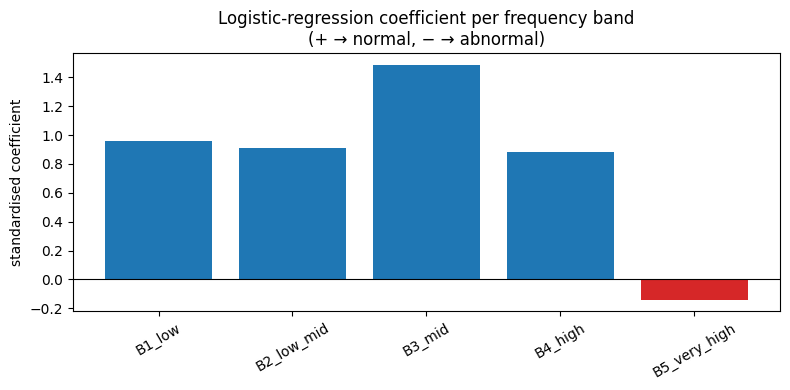

  B1_low        +0.961
  B2_low_mid    +0.907
  B3_mid        +1.486
  B4_high       +0.880
  B5_very_high  -0.140


In [7]:
coefs = model.named_steps["clf"].coef_.ravel()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["C0" if c >= 0 else "C3" for c in coefs]
ax.bar(band_names, coefs, color=colors)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title("Logistic-regression coefficient per frequency band\n(+ → normal, − → abnormal)")
ax.set_ylabel("standardised coefficient")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_band_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

for name, c in zip(band_names, coefs):
    print(f"  {name:<14}{c:+.3f}")

### The ground-truth read (the anchor)

The coefficients are **B1 +0.96, B2 +0.91, B3 +1.49, B4 +0.88, B5 −0.14**.

**The model relies most on the mid band, B3 (the QRS-core band), with the largest positive
weight (+1.49).** Reading it with the shared-budget caveat: **a beat whose energy is
concentrated in the mid/QRS band — rather than spread into the very-high band — is pushed
toward "normal."** The four lower/middle bands (B1–B4) all carry positive weight, while the
very-high band **B5 is weakly negative (−0.14)**: relatively more high-frequency content
(sharp, noise-like energy) nudges a beat toward "abnormal." So in one sentence:

> **The model relies most on mid-band (QRS) energy, treating energy concentrated there as the
> signature of a normal beat, and relatively elevated very-high-frequency energy as a weak
> signature of an abnormal beat.**

**Cross-check against notebook 01.** In the data-exploration notebook the two classes
separated mainly in the **early-to-middle portion of the beat** — the region containing the
QRS complex. The QRS is precisely the sharp mid-beat structure that shows up as **mid-band
frequency energy (B3)**. So the frequency-domain story here is **broadly consistent** with the
time-domain observation there: the model leans on the band tied to the beat region where the
classes actually differ. This is not a clean 1:1 mapping — frequency bands are not time
regions, and a single band's energy is smeared across the whole beat — but the two views
**agree on where the discriminative signal lives**, which is a reassuring sanity check on the
anchor.

## 6. Final test-set performance

We now evaluate **once** on the held-out 100-sample test set — the honest number for the
thesis. It is deliberately the last thing we touch so no choices were tuned on it.

In [8]:
y_test_pred = model.predict(F_test)
_ = report(y_test, y_test_pred, "test")

[test]  accuracy=0.700   balanced_accuracy=0.717   F1=0.737   (majority floor=0.640)


### Final result recorded

On the 100-beat test set the model scores **accuracy 0.70, balanced accuracy 0.72, F1 0.74**,
against a majority-class floor of **0.64**. So it **clears the baseline bar** — it is
genuinely learning from the frequency content rather than guessing the majority — but it is a
**modest** classifier, as expected for five hand-crafted features and a linear model. The drop
from the val scores (0.90) to test (0.70) is mostly the tiny (20-beat) validation set being
optimistic. For Model 1 this is exactly the intended outcome: a simple, honest, *interpretable*
baseline whose job is to be a trustworthy reference point, not to win on accuracy. Models 2–5
(CNNs, transformer) are expected to beat it — the thesis question is whether their explanations
stay as faithful as this model's built-in transparency.

## Note for later / thesis — the dual feature-space issue

**Record this now; nothing is implemented for it here.**

Model 1 lives in a **frequency-band feature space**: its inputs, coefficients, and the
ground-truth read above are all about *frequency bands*. But the cross-model faithfulness
comparison planned for the thesis (the CMI metric over Models 1–5) operates in a **time-region
space** — it perturbs *time segments* of the raw signal and measures the effect on the
prediction. Models 2–5 (CNNs, transformer) consume the raw 96-timestep signal directly, so
time-region attribution is native to them. Model 1 does not: it never sees time regions, only
band powers.

**Consequence.** Model 1 needs **two** interpretability checks to play its anchor role:

1. **A frequency-band ground-truth check — done in this notebook.** The coefficients tell us
   which bands the model relies on, and we will test whether TimeSHAP recovers them.
2. **A time-region CMI evaluation — later, not here.** To sit on the same axis as Models 2–5,
   Model 1's band-power pipeline must be wrapped so it can be probed in time-region space
   (e.g. by mapping band-power importance back onto the timeline, or by treating the whole
   filter→features→LR pipeline as a single function of the raw signal and perturbing time
   segments of that input). Only then are the five models comparable under one metric.

The open design question to resolve at that stage: **how to translate this model's
frequency-band reliance into a time-region attribution** without distorting either view.
Flagging it here so the anchor's dual role is explicit before the XAI work begins.